## Movie Recommender — EDA 

### Dataset
- **`ratings`**: interaction-level table (a user rated a movie at a time)
- **`movies`**: item-level metadata table (movieId → title, genres)



In [63]:
# Shared setup (imports + display + helper functions)

from __future__ import annotations

from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
import yaml

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def find_upwards(start: Path, target_name: str) -> Path:
    """Walk upwards from start to filesystem root to find a file."""
    start = start.resolve()
    for p in [start, *start.parents]:
        candidate = p / target_name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {target_name!r} when searching upwards from {start}"
    )


def discover_dataset_paths() -> tuple[Path, Path, Path, Path]:
    """Locate config.yaml, resolve source_dir, and find movies/ratings CSVs under it."""
    cwd = Path.cwd()
    config_path = find_upwards(cwd, "config.yaml")
    root = config_path.parent

    with config_path.open("r") as f:
        cfg = yaml.safe_load(f)

    source_dir_rel = cfg["data_dirs"]["source_dir"]
    source_dir = (root / source_dir_rel).resolve()

    if not source_dir.exists():
        raise FileNotFoundError(f"Configured source_dir does not exist: {source_dir}")

    def find_csv(root_dir: Path, filename: str) -> list[Path]:
        return sorted([p for p in root_dir.rglob(filename) if p.is_file()])

    movies_candidates = find_csv(source_dir, "movies.csv")
    ratings_candidates = find_csv(source_dir, "ratings.csv")

    if len(movies_candidates) != 1 or len(ratings_candidates) != 1:
        raise RuntimeError(
            "Expected exactly one movies.csv and one ratings.csv under source_dir. "
            f"Found movies={len(movies_candidates)}, ratings={len(ratings_candidates)}.\n"
            f"movies candidates: {movies_candidates}\n"
            f"ratings candidates: {ratings_candidates}"
        )

    return config_path, root, movies_candidates[0], ratings_candidates[0]


def guess_unix_unit_from_magnitude(ts: pd.Series) -> str:
    """Heuristic: decide whether UNIX timestamps are in seconds or milliseconds.

    MovieLens timestamps are usually seconds (~1e9). Milliseconds are ~1e12.
    """
    s = pd.to_numeric(ts, errors="coerce").dropna()
    if s.empty:
        return "s"  # default
    med = float(s.median())
    return "ms" if med >= 1e11 else "s"


def header(title: str) -> None:
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))

## STAGE 0 — Data Discovery & Loading

### Key questions
- Where are `movies.csv` and `ratings.csv` on disk?
- Do they load cleanly into DataFrames?
- Do expected columns exist?
- What dtype is `ratings.timestamp` before any conversion?


In [64]:
header("Stage 0 — Data Discovery & Loading")

config_path, root, movies_path, ratings_path = discover_dataset_paths()

print("CWD =", Path.cwd())
print("CONFIG_PATH =", config_path)
print("ROOT (config parent) =", root)
print("MOVIES_PATH =", movies_path)
print("RATINGS_PATH =", ratings_path)

movies = pd.read_csv(movies_path)
ratings = pd.read_csv(ratings_path)

print("\nMovies shape:", movies.shape)
display(movies.head(5))

print("\nRatings shape:", ratings.shape)
display(ratings.head(5))

expected_movies_cols = {"movieId"}
expected_ratings_cols = {"userId", "movieId", "rating", "timestamp"}

missing_movies = expected_movies_cols - set(movies.columns)
missing_ratings = expected_ratings_cols - set(ratings.columns)

print("\nMissing expected columns:")
print(" - movies missing:", sorted(missing_movies))
print(" - ratings missing:", sorted(missing_ratings))

print("\nratings['timestamp'] dtype:", ratings["timestamp"].dtype)
display(ratings["timestamp"].head(10))

# Keep a stable copy of columns list for later checks
movies_cols = list(movies.columns)
ratings_cols = list(ratings.columns)


Stage 0 — Data Discovery & Loading
CWD = /Users/lucasvanzyl/arrival-movie-recommender-5/backend/src/movie_recommender/services/recommender/pipeline/eda
CONFIG_PATH = /Users/lucasvanzyl/arrival-movie-recommender-5/backend/src/movie_recommender/services/recommender/config.yaml
ROOT (config parent) = /Users/lucasvanzyl/arrival-movie-recommender-5/backend/src/movie_recommender/services/recommender
MOVIES_PATH = /Users/lucasvanzyl/arrival-movie-recommender-5/backend/src/movie_recommender/services/recommender/pipeline/artifacts/dataset/source/small/movies.csv
RATINGS_PATH = /Users/lucasvanzyl/arrival-movie-recommender-5/backend/src/movie_recommender/services/recommender/pipeline/artifacts/dataset/source/small/ratings.csv

Movies shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings shape: (100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Missing expected columns:
 - movies missing: []
 - ratings missing: []

ratings['timestamp'] dtype: int64


0    964982703
1    964981247
2    964982224
3    964983815
4    964982931
5    964982400
6    964980868
7    964982176
8    964984041
9    964984100
Name: timestamp, dtype: int64

## STAGE 1 — Structural Audit

### Purpose
Understand what each table represents, what each row means, and what keys allow us to join them safely.

### Why now
Before measuring quality or distributions, we must confirm the **data model**: interactions vs metadata, and the join keys.

### Key questions
- What does a *row* represent in each table?
- What are the likely primary keys and join keys?
- Do the dtypes match the meaning (IDs vs numeric ratings vs timestamps)?


In [65]:
header("Stage 1 — Structural Audit")

print("movies columns:", movies_cols)
print("ratings columns:", ratings_cols)

print("\nmovies.dtypes:")
display(movies.dtypes)

print("\nratings.dtypes:")
display(ratings.dtypes)

print("\nmovies.sample(5):")
display(movies.sample(5, random_state=0))

print("\nratings.sample(5):")
display(ratings.sample(5, random_state=0))

# Row-level meaning (explicit, so later steps stay grounded)
print("\nRow meaning:")
print("- movies: one row per movieId (item metadata)")
print("- ratings: one row per (userId, movieId, timestamp) rating event (interaction)")

# Candidate keys
n_movies = len(movies)
n_movies_unique_movieId = movies["movieId"].nunique(dropna=False)
print("\nmovies key check:")
print("- rows:", n_movies)
print("- unique movieId:", n_movies_unique_movieId)

n_ratings = len(ratings)
unique_user_movie = ratings[["userId", "movieId"]].drop_duplicates().shape[0]
unique_user_movie_ts = (
    ratings[["userId", "movieId", "timestamp"]].drop_duplicates().shape[0]
)
print("\nratings key check:")
print("- rows:", n_ratings)
print("- unique (userId, movieId):", unique_user_movie)
print("- unique (userId, movieId, timestamp):", unique_user_movie_ts)

print("\nJoin key:")
print("- ratings.movieId joins to movies.movieId")


Stage 1 — Structural Audit
movies columns: ['movieId', 'title', 'genres']
ratings columns: ['userId', 'movieId', 'rating', 'timestamp']

movies.dtypes:


movieId    int64
title        str
genres       str
dtype: object


ratings.dtypes:


userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object


movies.sample(5):


,movieId,title,genres
272,313,"Swan Princess, The (1994)",Animation|Children
5665,27618,"Sound of Thunder, A (2005)",Action|Adventure|Drama|Sci-Fi|Thriller
3030,4054,Save the Last Dance (2001),Drama|Romance
4015,5673,Punch-Drunk Love (2002),Comedy|Drama|Romance
8557,116138,Leviathan (2014),Drama



ratings.sample(5):


,userId,movieId,rating,timestamp
41008,276,780,5.0,858350384
94274,599,7624,2.5,1519235950
77380,483,1320,2.5,1215895327
29744,202,3448,3.0,974924072
40462,274,60291,4.0,1296947017



Row meaning:
- movies: one row per movieId (item metadata)
- ratings: one row per (userId, movieId, timestamp) rating event (interaction)

movies key check:
- rows: 9742
- unique movieId: 9742

ratings key check:
- rows: 100836
- unique (userId, movieId): 100836
- unique (userId, movieId, timestamp): 100836

Join key:
- ratings.movieId joins to movies.movieId


## STAGE 2 — Data Quality Checks

### Purpose 
Check for problems that can mislead analysis: missing values, duplicates, invalid ranges, and ID consistency across tables.

### Why now
We want distributions and sparsity metrics to reflect **real signal**, not artifacts from bad rows or inconsistent IDs.

### Key questions
- Are there missing values in critical columns?
- Are there exact duplicate rows?
- Are rating values within a plausible scale?
- Do all `ratings.movieId` values exist in `movies.movieId`?
- Are there obvious impossible values (negative IDs, timestamps, etc.)?


In [66]:
header("Stage 2 — Data Quality Checks")

# Missingness
print("Missing values (count):")
display(
    pd.DataFrame(
        {
            "movies": movies.isna().sum(),
            "ratings": ratings.isna().sum(),
        }
    )
    .fillna(0)
    .astype(int)
)

# Duplicate rows
movies_dupes = movies.duplicated().sum()
ratings_dupes = ratings.duplicated().sum()
print("\nExact duplicate rows:")
print("- movies:", int(movies_dupes))
print("- ratings:", int(ratings_dupes))

# Duplicate keys (more meaningful than full-row dupes)
movies_dupe_movieId = movies.duplicated(subset=["movieId"]).sum()
print("\nDuplicate movieId rows in movies:", int(movies_dupe_movieId))

ratings_dupe_user_movie_ts = ratings.duplicated(
    subset=["userId", "movieId", "timestamp"]
).sum()
print(
    "Duplicate (userId, movieId, timestamp) rows in ratings:",
    int(ratings_dupe_user_movie_ts),
)

# Rating scale validity
rating_min = float(ratings["rating"].min())
rating_max = float(ratings["rating"].max())
print("\nRating range:")
print("- min:", rating_min)
print("- max:", rating_max)

# Common MovieLens expectation is 0.5 increments; we *check* rather than assume.
unique_ratings = sorted(ratings["rating"].dropna().unique())
print("\nUnique rating values (sorted, first 30):")
print(unique_ratings[:30], "..." if len(unique_ratings) > 30 else "")

# ID sanity (simple checks)
print("\nID sanity checks:")
print("- any userId <= 0:", bool((ratings["userId"] <= 0).any()))
print("- any movieId <= 0 in ratings:", bool((ratings["movieId"] <= 0).any()))
print("- any movieId <= 0 in movies:", bool((movies["movieId"] <= 0).any()))

# Join consistency: ratings.movieId must be in movies.movieId
movies_movie_ids = set(movies["movieId"].unique())
ratings_movie_ids = set(ratings["movieId"].unique())
missing_in_movies = sorted(list(ratings_movie_ids - movies_movie_ids))
print("\nJoin consistency:")
print("- unique movieId in ratings:", len(ratings_movie_ids))
print("- unique movieId in movies:", len(movies_movie_ids))
print("- movieIds in ratings missing from movies:", len(missing_in_movies))
if missing_in_movies:
    print("  Example missing movieIds:", missing_in_movies[:20])

# Timestamp sanity (do not convert yet)
print("\nTimestamp summary (raw int64):")
display(ratings["timestamp"].describe())


Stage 2 — Data Quality Checks
Missing values (count):


,movies,ratings
genres,0,0
movieId,0,0
rating,0,0
timestamp,0,0
title,0,0
userId,0,0



Exact duplicate rows:
- movies: 0
- ratings: 0

Duplicate movieId rows in movies: 0
Duplicate (userId, movieId, timestamp) rows in ratings: 0

Rating range:
- min: 0.5
- max: 5.0

Unique rating values (sorted, first 30):
[np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)] 

ID sanity checks:
- any userId <= 0: False
- any movieId <= 0 in ratings: False
- any movieId <= 0 in movies: False

Join consistency:
- unique movieId in ratings: 9724
- unique movieId in movies: 9742
- movieIds in ratings missing from movies: 0

Timestamp summary (raw int64):


count    1.008360e+05
mean     1.205946e+09
std      2.162610e+08
min      8.281246e+08
25%      1.019124e+09
50%      1.186087e+09
75%      1.435994e+09
max      1.537799e+09
Name: timestamp, dtype: float64

### What this means 
 I’m seeing a clean, internally consistent dataset (no missing values, no duplicates, valid IDs, valid MovieLens-style 0.5–5.0 rating scale, and every rated movieId exists in movies).
### Potential conclusion
I can trust downstream coverage/sparsity and behavior analyses without worrying that basic data-quality issues (nulls/dupes/bad joins/out-of-range ratings) are driving the results, and I can treat timestamp as plausible Unix seconds spanning a real multi-year period.

## STAGE 3 — Coverage & Sparsity

### Purpose 
Quantify how much data we have at interaction/user/item levels and how sparse the user–item matrix is.

### Why now
Sparsity drives what kinds of conclusions are reliable (e.g., user-level stats vs item-level popularity) and foreshadows whether cold-start/long-tail effects will matter.

### Key questions
- How many total interactions?
- How many unique users?
- How many unique movies are rated vs in the catalog?
- What is the implied interaction matrix density?


In [67]:
header("Stage 3 — Coverage & Sparsity")

n_interactions = len(ratings)
n_users = ratings["userId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_movies_catalog = movies["movieId"].nunique()

print("Interaction-level:")
print("- total interactions (rows in ratings):", n_interactions)

print("\nUser-level:")
print("- unique users:", n_users)

print("\nItem-level:")
print("- unique movies rated (in ratings):", n_movies_rated)
print("- unique movies in catalog (in movies):", n_movies_catalog)

# Density of the user-item matrix (only over rated-movie universe)
density = n_interactions / (n_users * n_movies_rated)
print("\nUser–item matrix density (interactions / (users * rated_movies)):")
print("- density:", density)
print("- sparsity (1 - density):", 1 - density)


Stage 3 — Coverage & Sparsity
Interaction-level:
- total interactions (rows in ratings): 100836

User-level:
- unique users: 610

Item-level:
- unique movies rated (in ratings): 9724
- unique movies in catalog (in movies): 9742

User–item matrix density (interactions / (users * rated_movies)):
- density: 0.016999683055613623
- sparsity (1 - density): 0.9830003169443864


### What this means
I’m seeing that the dataset has 100,836 interactions across 610 users and 9,724 rated movies (out of 9,742 in the catalog), producing an extremely sparse user–item matrix with density ≈ 0.017 and sparsity ≈ 0.983.

### Potential conclusion
I should expect long-tail and cold-start challenges where most user–movie pairs are unobserved, so robust conclusions and future modeling will need strong regularization and careful evaluation rather than assuming dense preference coverage.



## STAGE 4 — Raw Rating Signal Analysis

### Purpose 
Understand the *raw* rating signal: its distribution, central tendency, spread, and potential biases.

### Why now
Before aggregating by user or movie, we should learn what a single rating means statistically (e.g., are ratings mostly high? discrete? skewed?).

### Key questions
- What rating values are used and how often?
- Is there positivity bias (ratings clustered high)?
- Are ratings sufficiently variable to be informative?



Stage 4 — Raw Rating Signal Analysis
Summary statistics (ratings):


count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


Skewness / Kurtosis:
- skew: -0.6371993892529213
- kurtosis: 0.12331407123922533

Rating value counts:


,count
rating,
0.5,1370
1.0,2811
1.5,1791
2.0,7551
2.5,5550
3.0,20047
3.5,13136
4.0,26818
4.5,8551


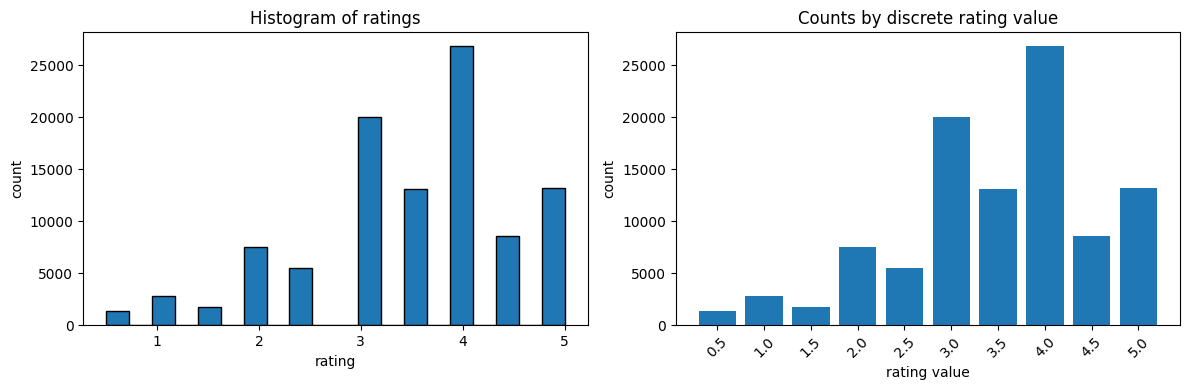

In [68]:
header("Stage 4 — Raw Rating Signal Analysis")

rating = ratings["rating"].astype(float)

print("Summary statistics (ratings):")
display(rating.describe())

print("\nSkewness / Kurtosis:")
print("- skew:", float(rating.skew()))
print("- kurtosis:", float(rating.kurtosis()))

# Value counts
rating_counts = rating.value_counts().sort_index()
print("\nRating value counts:")
display(rating_counts.to_frame("count"))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rating, bins=20, edgecolor="black")
axes[0].set_title("Histogram of ratings")
axes[0].set_xlabel("rating")
axes[0].set_ylabel("count")

axes[1].bar(rating_counts.index.astype(str), rating_counts.values)
axes[1].set_title("Counts by discrete rating value")
axes[1].set_xlabel("rating value")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### What this means
I’m seeing that ratings are discrete in 0.5 steps and are heavily concentrated around higher values (especially 3.0–5.0, with 4.0 being the dominant mode), indicating a positivity-skewed rating signal.

### Potential conclusion
I should treat “missing interaction” as ambiguous (not necessarily dislike) and be cautious about naive thresholds, because the dataset’s raw ratings reflect generally positive feedback rather than a balanced like/dislike distribution.



## STAGE 5 — User-Level Behavior

### Purpose 
Understand how users behave: how many ratings each user contributes and whether behavior is dominated by a small number of heavy raters.

### Why now
User activity heterogeneity (heavy vs light users) affects the reliability of user preference signals and can create bias in aggregates.

### Key questions
- What is the distribution of ratings per user?
- How extreme are the tails (very active vs very inactive users)?
- How much of the data is contributed by the most active users?



Stage 5 — User-Level Behavior
Ratings per user — summary:


count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: n_ratings, dtype: float64

Top 1% users contribute 11.70% of all ratings
Top 5% users contribute 32.64% of all ratings
Top 10% users contribute 47.72% of all ratings


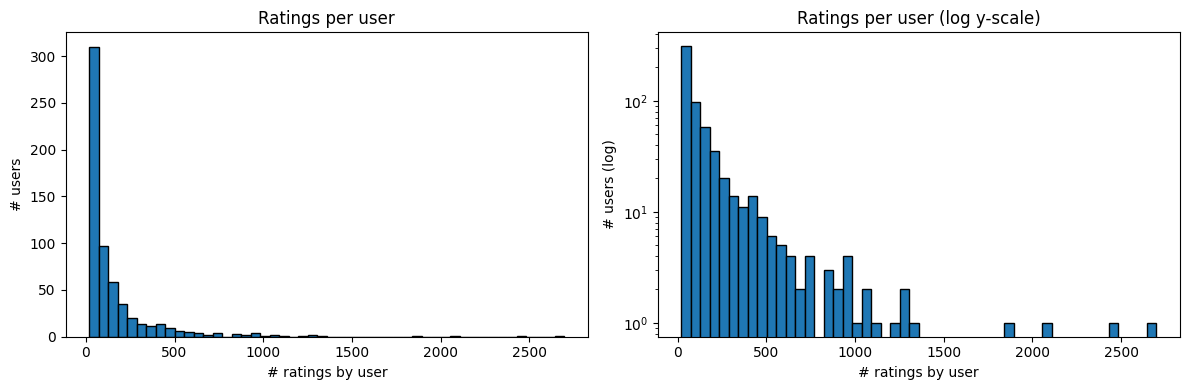

In [69]:
header("Stage 5 — User-Level Behavior")

ratings_per_user = ratings.groupby("userId").size().rename("n_ratings")

print("Ratings per user — summary:")
display(ratings_per_user.describe())


# Tail contribution: what fraction of interactions come from top X% users?
def top_fraction_contribution(counts: pd.Series, top_frac: float) -> float:
    counts_sorted = counts.sort_values(ascending=False)
    k = max(1, int(round(len(counts_sorted) * top_frac)))
    return float(counts_sorted.head(k).sum() / counts_sorted.sum())


for top_frac in [0.01, 0.05, 0.10]:
    contrib = top_fraction_contribution(ratings_per_user, top_frac)
    print(f"Top {int(top_frac * 100)}% users contribute {contrib:.2%} of all ratings")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ratings_per_user, bins=50, edgecolor="black")
axes[0].set_title("Ratings per user")
axes[0].set_xlabel("# ratings by user")
axes[0].set_ylabel("# users")

axes[1].hist(ratings_per_user, bins=50, edgecolor="black", log=True)
axes[1].set_title("Ratings per user (log y-scale)")
axes[1].set_xlabel("# ratings by user")
axes[1].set_ylabel("# users (log)")

plt.tight_layout()
plt.show()

### What this means
I’m seeing a highly right-skewed user activity distribution where most users rate relatively few movies (median ~70.5) but a small minority are extremely active (up to ~2698 ratings), and the top 10% of users contribute ~47.7% of all ratings.

### Potential conclusion
I should expect heavy-user dominance in aggregate signals (and potential bias toward heavy-user preferences), so any “average user” conclusions need to account for this long-tail rather than assuming users contribute equally.



## STAGE 6 — Item-Level Behavior

### Purpose 
Understand how movies behave: how many ratings each movie receives and whether interactions concentrate on a small head of popular items.

### Why now
Item popularity skew (long-tail) influences what users see, what the data can learn, and how stable movie-level statistics are.

### Key questions
- What is the distribution of ratings per movie?
- Is there long-tail behavior (many items with few interactions)?
- Do a few items dominate the interaction volume?



Stage 6 — Item-Level Behavior
Ratings per movie — summary:


count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
Name: n_ratings, dtype: float64

Top 1% movies contribute 15.71% of all ratings
Top 5% movies contribute 42.73% of all ratings
Top 10% movies contribute 60.02% of all ratings


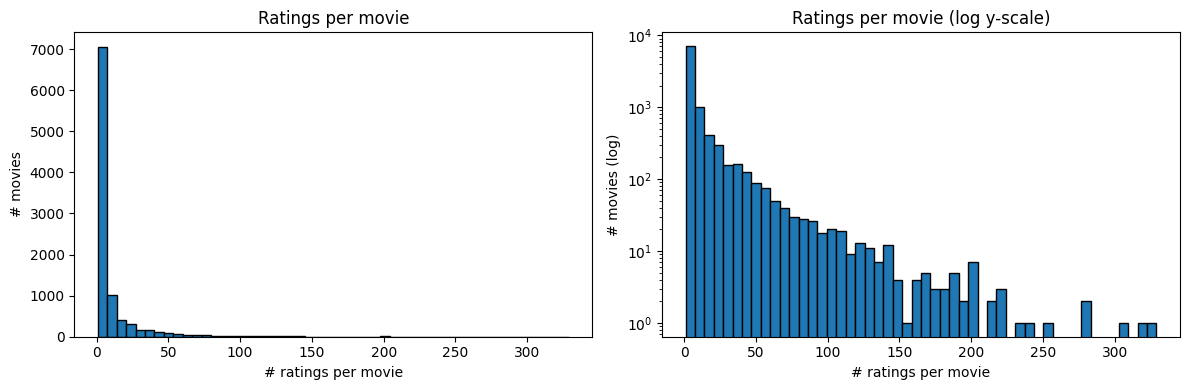

In [70]:
header("Stage 6 — Item-Level Behavior")

ratings_per_movie = ratings.groupby("movieId").size().rename("n_ratings")

print("Ratings per movie — summary:")
display(ratings_per_movie.describe())

for top_frac in [0.01, 0.05, 0.10]:
    contrib = float(
        ratings_per_movie.sort_values(ascending=False)
        .head(max(1, int(round(len(ratings_per_movie) * top_frac))))
        .sum()
        / ratings_per_movie.sum()
    )
    print(f"Top {int(top_frac * 100)}% movies contribute {contrib:.2%} of all ratings")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ratings_per_movie, bins=50, edgecolor="black")
axes[0].set_title("Ratings per movie")
axes[0].set_xlabel("# ratings per movie")
axes[0].set_ylabel("# movies")

axes[1].hist(ratings_per_movie, bins=50, edgecolor="black", log=True)
axes[1].set_title("Ratings per movie (log y-scale)")
axes[1].set_xlabel("# ratings per movie")
axes[1].set_ylabel("# movies (log)")

plt.tight_layout()
plt.show()

### What this means
I’m seeing an extremely long-tailed item popularity distribution where most movies have very few ratings (median ~3, 75% ≤ 9) but a small head of movies is rated a lot (up to ~329), and the top 10% of movies account for ~60.0% of all ratings.

### Potential conclusion
I should expect strong popularity bias and many items with unstable estimates due to low support, so any item-level insights need to distinguish “popular head” behavior from the sparse long tail.



## STAGE 7 — Temporal Analysis

### Purpose 
Understand *when* interactions happen: overall volume over time, and whether user/item activity changes, bursts, or trends.

### Why now
Time effects can change how we interpret ratings (e.g., seasonality, catalog growth) and whether temporal splitting would ever be justified later.

### Key questions
- Over time, do interactions increase/decrease or cluster?
- Are there bursts or gaps suggesting logging artifacts?
- Do new movies/users appear gradually or suddenly?



Stage 7 — Temporal Analysis
Guessed UNIX timestamp unit: s

Converted datetime summary:
- non-null ts: 100836
- ts_min: 1996-03-29 18:36:55
- ts_max: 2018-09-24 14:27:30
- NaT after conversion: 0


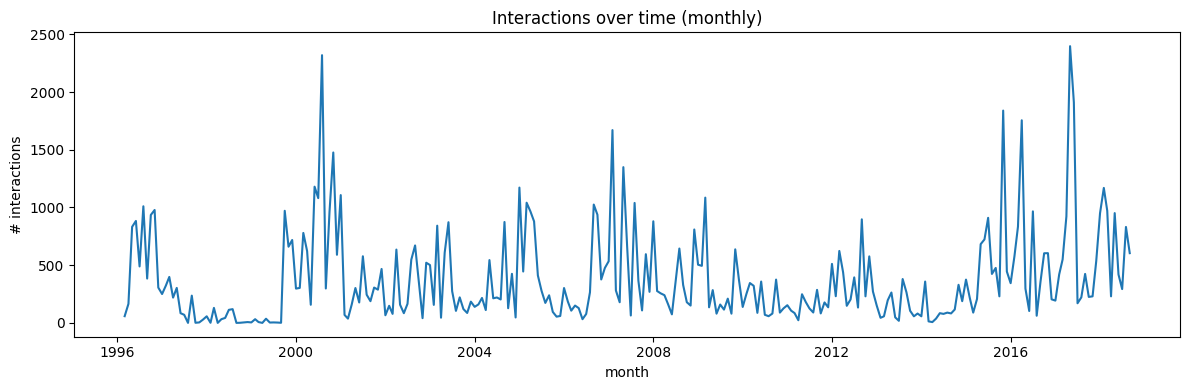

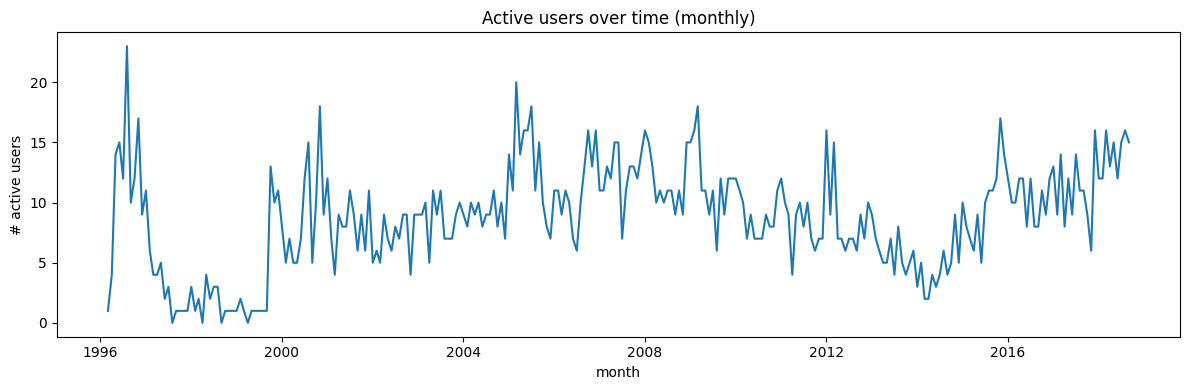

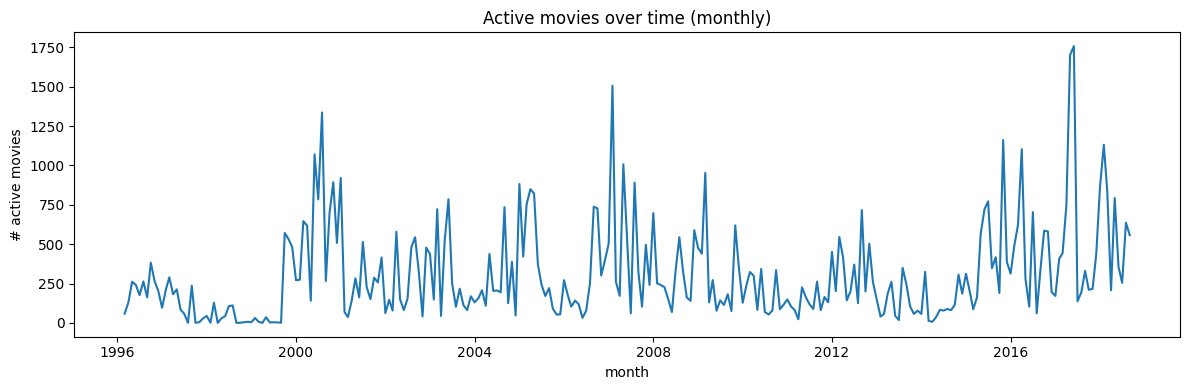

In [71]:
header("Stage 7 — Temporal Analysis")

# Convert timestamp to datetime *only here*.
unit = guess_unix_unit_from_magnitude(ratings["timestamp"])
print("Guessed UNIX timestamp unit:", unit)

ratings_time = ratings.copy()
ratings_time["ts"] = pd.to_datetime(
    ratings_time["timestamp"], unit=unit, errors="coerce"
)

# Pandas versions differ on whether describe() supports datetime-specific flags.
# We keep it version-agnostic and summarize explicitly.
print("\nConverted datetime summary:")
print("- non-null ts:", int(ratings_time["ts"].notna().sum()))
print("- ts_min:", ratings_time["ts"].min())
print("- ts_max:", ratings_time["ts"].max())

# If coercion produced NaT, that is a quality signal.
num_nat = int(ratings_time["ts"].isna().sum())
print("- NaT after conversion:", num_nat)

# Interactions over time (monthly)
monthly = (
    ratings_time.dropna(subset=["ts"])
    .set_index("ts")
    .resample("MS")
    .size()
    .rename("n_interactions")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly.values)
ax.set_title("Interactions over time (monthly)")
ax.set_xlabel("month")
ax.set_ylabel("# interactions")
plt.tight_layout()
plt.show()

# Active users over time (monthly)
monthly_active_users = (
    ratings_time.dropna(subset=["ts"])
    .set_index("ts")
    .groupby(pd.Grouper(freq="MS"))["userId"]
    .nunique()
    .rename("n_active_users")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_active_users.index, monthly_active_users.values)
ax.set_title("Active users over time (monthly)")
ax.set_xlabel("month")
ax.set_ylabel("# active users")
plt.tight_layout()
plt.show()

# Active movies over time (monthly)
monthly_active_movies = (
    ratings_time.dropna(subset=["ts"])
    .set_index("ts")
    .groupby(pd.Grouper(freq="MS"))["movieId"]
    .nunique()
    .rename("n_active_movies")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_active_movies.index, monthly_active_movies.values)
ax.set_title("Active movies over time (monthly)")
ax.set_xlabel("month")
ax.set_ylabel("# active movies")
plt.tight_layout()
plt.show()

### What this means
I’m seeing timestamps that convert cleanly as Unix seconds with full coverage (no NaT) spanning ~1996 to ~2018, and the monthly interaction/user/item activity is highly non-stationary with pronounced spikes and regime changes over time.

### Potential conclusion
I should be cautious about random splits or “overall average” temporal conclusions, because the data-generating process appears to change over time, which could justify a time-aware evaluation approach later if we want realistic forward-looking performance.



## STAGE 8 — Metadata Inspection

### Purpose 
Inspect the `movies` metadata and how it enriches interactions when merged.

### Why now
After we understand interactions and time patterns, we can check whether metadata is complete/usable and what simple, evidence-supported feature extraction might be possible.

### Key questions
- Are titles/genres present and well-formed?
- Are there missing/empty genres?
- Does merging ratings→movies work cleanly?
- Is extracting year from title feasible (and how noisy is it)?



Stage 8 — Metadata Inspection
movies missingness:


,missing_count
movieId,0
title,0
genres,0



Empty-like titles: 0
Empty-like genres: 0

After merging ratings→movies:
- rows: 100836
- missing title (unmatched movieId): 0


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller



Top genres (by movie count):


,n_movies
genres,
Drama,4361
Comedy,3756
Thriller,1894
Action,1828
Romance,1596
Adventure,1263
Crime,1199
Sci-Fi,980
Horror,978


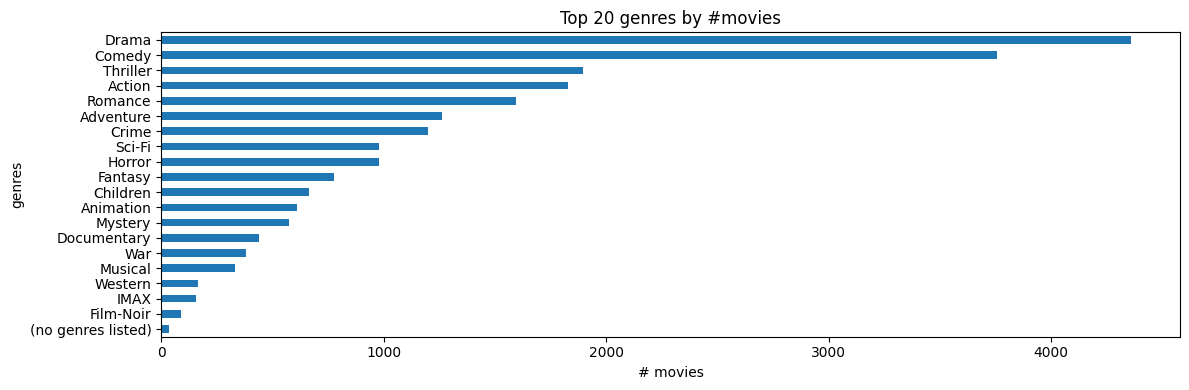


Year extraction:
- missing year: 13


,title,year
272,"Swan Princess, The (1994)",1994.0
5665,"Sound of Thunder, A (2005)",2005.0
3030,Save the Last Dance (2001),2001.0
4015,Punch-Drunk Love (2002),2002.0
8557,Leviathan (2014),2014.0
5350,Team America: World Police (2004),2004.0
683,Funny Face (1957),1957.0
7032,Were the World Mine (2008),2008.0
9737,Black Butler: Book of the Atlantic (2017),2017.0
8650,Taken 3 (2015),2015.0


count    9729.000000
mean     1994.613629
std        18.535219
min      1902.000000
25%      1988.000000
50%      1999.000000
75%      2008.000000
max      2018.000000
Name: year, dtype: float64

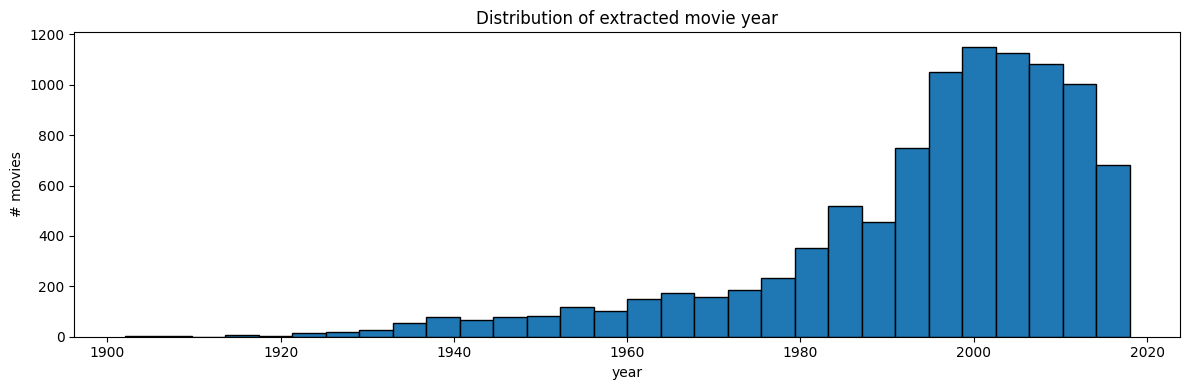

In [72]:
header("Stage 8 — Metadata Inspection")

print("movies missingness:")
display(movies.isna().sum().to_frame("missing_count"))

# Basic string quality checks
movies_str = movies.copy()
movies_str["title"] = movies_str["title"].astype(str)
movies_str["genres"] = movies_str["genres"].astype(str)

print("\nEmpty-like titles:", int((movies_str["title"].str.strip() == "").sum()))
print("Empty-like genres:", int((movies_str["genres"].str.strip() == "").sum()))

# Merge a sample of ratings with movies to verify enrichability
ratings_movies = ratings.merge(movies, on="movieId", how="left", validate="many_to_one")

missing_metadata = ratings_movies["title"].isna().sum()
print("\nAfter merging ratings→movies:")
print("- rows:", len(ratings_movies))
print("- missing title (unmatched movieId):", int(missing_metadata))

display(ratings_movies.head(5))

# Genres structure: split pipe-separated values and count genre tokens
# (No filtering; just descriptive counts.)
all_genres = movies_str["genres"].str.split("|").explode().str.strip()

genre_counts = all_genres.value_counts(dropna=False)
print("\nTop genres (by movie count):")
display(genre_counts.head(20).to_frame("n_movies"))

fig, ax = plt.subplots(figsize=(12, 4))
genre_counts.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 genres by #movies")
ax.set_xlabel("# movies")
plt.tight_layout()
plt.show()

# Year extraction feasibility (simple regex for '(YYYY)' at end)
pattern = re.compile(r"\((\d{4})\)\s*$")


def extract_year(title: str) -> float:
    m = pattern.search(title)
    return float(m.group(1)) if m else float("nan")


movies_with_year = movies.copy()
movies_with_year["year"] = movies_str["title"].map(extract_year)

print("\nYear extraction:")
print("- missing year:", int(movies_with_year["year"].isna().sum()))
display(movies_with_year[["title", "year"]].sample(10, random_state=0))

display(movies_with_year["year"].describe())

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(movies_with_year["year"].dropna(), bins=30, edgecolor="black")
ax.set_title("Distribution of extracted movie year")
ax.set_xlabel("year")
ax.set_ylabel("# movies")
plt.tight_layout()
plt.show()

### What this means
I’m seeing complete and joinable movie metadata (no missing title/genres, perfect ratings→movies merge) with a sensible genre taxonomy dominated by Drama/Comedy and a mostly successful year extraction from titles (only 13 missing, years spanning ~1902–2018).

### Potential conclusion
I can confidently use genres and extracted year as metadata features later (with a small exception-handling step for the few missing years/“(no genres listed)”), because the metadata is high-quality and integrates cleanly with interactions.



## STAGE 9 — Synthesis & Evidence-Based Decisions

### Purpose 
Summarize what we observed (facts), what we assume (explicit), and what decisions would be justified *based on evidence*.

### Why now
Filtering, binarization, and splitting are **interventions**. We only propose them after we’ve measured data quality, sparsity, behavior, and time patterns.

### Key questions
- What are the key interaction/user/item-level findings?
- Would filtering users/items be justified (and at what thresholds), or is it premature?
- Does rating scale/positivity bias suggest binarization later?
- Do temporal patterns suggest time-based splitting later?


In [73]:
header("Stage 9 — Synthesis & Evidence-Based Decisions")

# Facts: interaction/user/item coverage
facts = {
    "n_interactions": int(len(ratings)),
    "n_users": int(ratings["userId"].nunique()),
    "n_movies_rated": int(ratings["movieId"].nunique()),
    "n_movies_catalog": int(movies["movieId"].nunique()),
    "rating_min": float(ratings["rating"].min()),
    "rating_max": float(ratings["rating"].max()),
}

print("FACTS (directly observed):")
for k, v in facts.items():
    print(f"- {k}: {v}")

# Facts: distribution tails (user + item)
ratings_per_user = ratings.groupby("userId").size()
ratings_per_movie = ratings.groupby("movieId").size()

print("\nUSER-LEVEL FACTS:")
print(
    "- ratings per user (min/median/mean/max):",
    int(ratings_per_user.min()),
    float(ratings_per_user.median()),
    float(ratings_per_user.mean()),
    int(ratings_per_user.max()),
)

print("\nITEM-LEVEL FACTS:")
print(
    "- ratings per movie (min/median/mean/max):",
    int(ratings_per_movie.min()),
    float(ratings_per_movie.median()),
    float(ratings_per_movie.mean()),
    int(ratings_per_movie.max()),
)

# Evidence-guided candidate thresholds (NOT applied; just reported)
# Use percentiles to propose what "rare" looks like in this dataset.
user_q = ratings_per_user.quantile([0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])
movie_q = ratings_per_movie.quantile([0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99])

print("\nQuantiles — ratings per user:")
display(user_q.to_frame("n_ratings"))

print("Quantiles — ratings per movie:")
display(movie_q.to_frame("n_ratings"))

# Timestamp unit + date range (from Stage 7 conversion)
unit = guess_unix_unit_from_magnitude(ratings["timestamp"])
ratings_time = ratings.copy()
ratings_time["ts"] = pd.to_datetime(
    ratings_time["timestamp"], unit=unit, errors="coerce"
)

ts_min = ratings_time["ts"].min()
ts_max = ratings_time["ts"].max()
print("\nTEMPORAL FACTS:")
print("- timestamp unit guess:", unit)
print("- ts_min:", ts_min)
print("- ts_max:", ts_max)

# Decision discussion (explicitly separated)
print("\nDECISION GUIDANCE:")

print("\n1) Filtering users/items")
print("- Evidence to consider: heavy tails in ratings_per_user and ratings_per_movie.")
print(
    "- A principled next step (if needed later): choose thresholds based on quantiles + downstream stability tests."
)
print(
    "- For now: do NOT filter in EDA; just document potential cutoffs and what % of data they'd remove."
)

print("\n2) Binarization (likes/dislikes)")
print("- Evidence to consider: rating distribution shape and positivity bias.")
print(
    "- If ratings are concentrated at high values, naive binarization can discard useful gradation."
)
print(
    "- For now: keep raw ratings; only binarize if a downstream objective demands it and EDA supports it."
)

print("\n3) Temporal splits")
print(
    "- Evidence to consider: whether interaction volume changes materially over time and whether recency effects are strong."
)
print("- If there are clear trends/bursts, random splits can leak time patterns.")
print(
    "- For now: we only report the date range and time series; decide splits later if justified."
)


Stage 9 — Synthesis & Evidence-Based Decisions
FACTS (directly observed):
- n_interactions: 100836
- n_users: 610
- n_movies_rated: 9724
- n_movies_catalog: 9742
- rating_min: 0.5
- rating_max: 5.0

USER-LEVEL FACTS:
- ratings per user (min/median/mean/max): 20 70.5 165.30491803278687 2698

ITEM-LEVEL FACTS:
- ratings per movie (min/median/mean/max): 1 3.0 10.369806663924312 329

Quantiles — ratings per user:


,n_ratings
0.01,20.00
0.05,22.00
0.10,24.00
0.50,70.50
0.90,400.30
0.95,610.75
0.99,1256.22


Quantiles — ratings per movie:


,n_ratings
0.01,1.00
0.05,1.00
0.10,1.00
0.50,3.00
0.90,27.00
0.95,47.00
0.99,114.54



TEMPORAL FACTS:
- timestamp unit guess: s
- ts_min: 1996-03-29 18:36:55
- ts_max: 2018-09-24 14:27:30

DECISION GUIDANCE:

1) Filtering users/items
- Evidence to consider: heavy tails in ratings_per_user and ratings_per_movie.
- A principled next step (if needed later): choose thresholds based on quantiles + downstream stability tests.
- For now: do NOT filter in EDA; just document potential cutoffs and what % of data they'd remove.

2) Binarization (likes/dislikes)
- Evidence to consider: rating distribution shape and positivity bias.
- If ratings are concentrated at high values, naive binarization can discard useful gradation.
- For now: keep raw ratings; only binarize if a downstream objective demands it and EDA supports it.

3) Temporal splits
- Evidence to consider: whether interaction volume changes materially over time and whether recency effects are strong.
- If there are clear trends/bursts, random splits can leak time patterns.
- For now: we only report the date range and ti

### What this means
I’m seeing a moderately sized but very sparse interaction dataset (100,836 ratings over 610 users and 9,724 rated movies) with strong heavy-tail behavior at both user and item levels and a long temporal span from 1996 to 2018.

### Potential conclusion
I should keep raw ratings and avoid premature filtering, but I can justify documenting candidate minimum-support thresholds (e.g., users < ~24 ratings and movies with 1 rating are extremely common) and seriously consider time-aware evaluation later if I want conclusions that generalize across the dataset’s non-stationary timeline.



## STAGE 10 — Advanced Diagnostic & Upgrade Layer

This stage **deepens** earlier EDA by quantifying long-tail dominance, diagnosing user/item biases, analyzing temporal drift, measuring sparsity and cold-start severity, linking metadata to behavior, and adding multivariate stability/controversy signals.

**Constraint reminders**
- build on existing variables (`ratings`, `movies`, helpers)
- separate **Observation vs Interpretation vs Implication**


In [74]:
header("Stage 10 — Setup (derived tables)")

# Build a canonical ratings table with datetime for Stage 10.
unit = guess_unix_unit_from_magnitude(ratings["timestamp"])
ratings_t = ratings.copy()
ratings_t["ts"] = pd.to_datetime(ratings_t["timestamp"], unit=unit, errors="coerce")

# Merge interactions with movie metadata (validate many-to-one).
ratings_m = ratings_t.merge(movies, on="movieId", how="left", validate="many_to_one")

# Interaction counts
user_counts = ratings_t.groupby("userId").size().rename("n")
item_counts = ratings_t.groupby("movieId").size().rename("n")

# Convenience scalars
N = len(ratings_t)
U = int(ratings_t["userId"].nunique())
I_rated = int(ratings_t["movieId"].nunique())
I_catalog = int(movies["movieId"].nunique())

print("Derived tables ready:")
print("- ratings_t: ratings + ts")
print("- ratings_m: ratings + ts + movies metadata")
print("- user_counts, item_counts")
print("\nKey sizes:")
print("- interactions N:", N)
print("- users U:", U)
print("- rated_movies I_rated:", I_rated)
print("- catalog_movies I_catalog:", I_catalog)


Stage 10 — Setup (derived tables)
Derived tables ready:
- ratings_t: ratings + ts
- ratings_m: ratings + ts + movies metadata
- user_counts, item_counts

Key sizes:
- interactions N: 100836
- users U: 610
- rated_movies I_rated: 9724
- catalog_movies I_catalog: 9742


### 10.1 Long-tail & Inequality Analysis

Compute Gini coefficients and Lorenz curves for user and item interaction counts, and quantify concentration from top 10% users/items.



Stage 10.1 — Long-tail & Inequality
OBSERVATION (metrics):
- Gini(user interaction counts): 0.604
- Gini(item interaction counts): 0.716
- Share of interactions from top 10% users: 47.72%
- Share of interactions from top 10% items: 60.05%


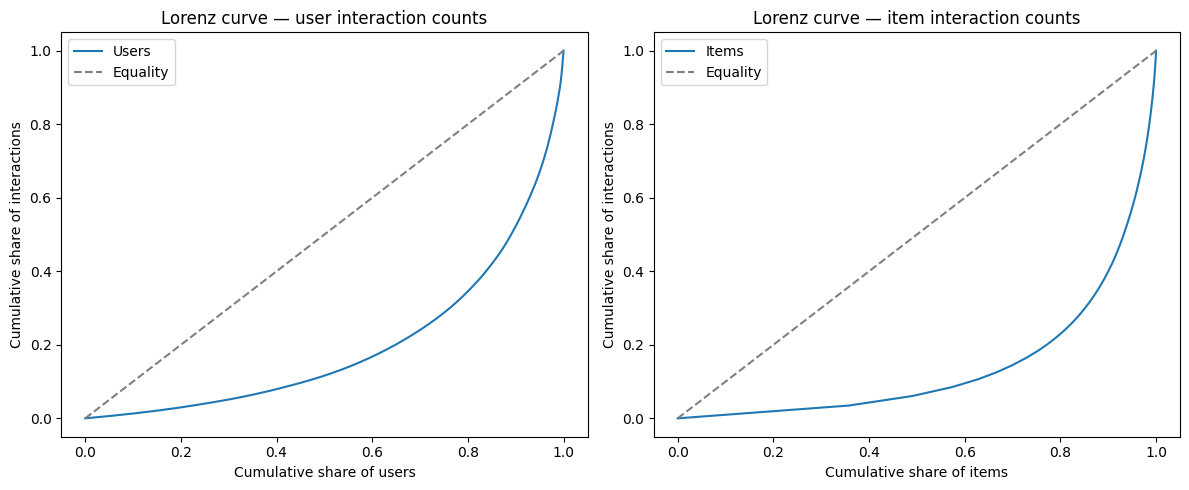

In [75]:
header("Stage 10.1 — Long-tail & Inequality")

import numpy as np


def gini(x: pd.Series) -> float:
    """Gini coefficient for non-negative values."""
    arr = np.asarray(x, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return float("nan")
    if (arr < 0).any():
        raise ValueError("Gini is undefined for negative values")
    if arr.sum() == 0:
        return 0.0
    arr = np.sort(arr)
    n = arr.size
    idx = np.arange(1, n + 1)
    return float((2 * (idx * arr).sum()) / (n * arr.sum()) - (n + 1) / n)


def lorenz_curve(x: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(x, dtype=float)
    arr = arr[np.isfinite(arr)]
    arr = np.sort(arr)
    if arr.size == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0])
    cum = np.cumsum(arr)
    cum_share = np.insert(cum / cum[-1], 0, 0.0)
    pop_share = np.linspace(0.0, 1.0, cum_share.size)
    return pop_share, cum_share


def top_k_share(counts: pd.Series, frac: float) -> float:
    s = counts.sort_values(ascending=False)
    k = max(1, int(np.ceil(len(s) * frac)))
    return float(s.head(k).sum() / s.sum())


gini_users = gini(user_counts)
gini_items = gini(item_counts)

share_top10_users = top_k_share(user_counts, 0.10)
share_top10_items = top_k_share(item_counts, 0.10)

print("OBSERVATION (metrics):")
print(f"- Gini(user interaction counts): {gini_users:.3f}")
print(f"- Gini(item interaction counts): {gini_items:.3f}")
print(f"- Share of interactions from top 10% users: {share_top10_users:.2%}")
print(f"- Share of interactions from top 10% items: {share_top10_items:.2%}")

# Lorenz curves
pu, lu = lorenz_curve(user_counts)
pi, li = lorenz_curve(item_counts)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(pu, lu, label="Users")
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Equality")
ax[0].set_title("Lorenz curve — user interaction counts")
ax[0].set_xlabel("Cumulative share of users")
ax[0].set_ylabel("Cumulative share of interactions")
ax[0].legend()

ax[1].plot(pi, li, label="Items")
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Equality")
ax[1].set_title("Lorenz curve — item interaction counts")
ax[1].set_xlabel("Cumulative share of items")
ax[1].set_ylabel("Cumulative share of interactions")
ax[1].legend()

plt.tight_layout()
plt.show()

### What this means
I’m seeing strong inequality in both user activity and item popularity (Gini users ≈ 0.604, Gini items ≈ 0.716) where the top 10% of users generate ~47.7% of interactions and the top 10% of items receive ~60.1%, as reflected by the sharply bowed Lorenz curves.

### Potential conclusion
I should expect pronounced activity/popularity bias and design modeling/evaluation to avoid overfitting to heavy users and head items (e.g., strong regularization, debiasing or reweighting, and tail-aware reporting).



### 10.2 User & Item Bias Diagnostics

Test whether **activity/popularity** is associated with systematically different average ratings.



Stage 10.2 — User & Item Bias Diagnostics
OBSERVATION (correlations):
- corr(user_n_ratings, user_avg_rating) Pearson: -0.199 | Spearman: -0.135
- corr(item_n_ratings, item_avg_rating) Pearson: 0.127 | Spearman: 0.040


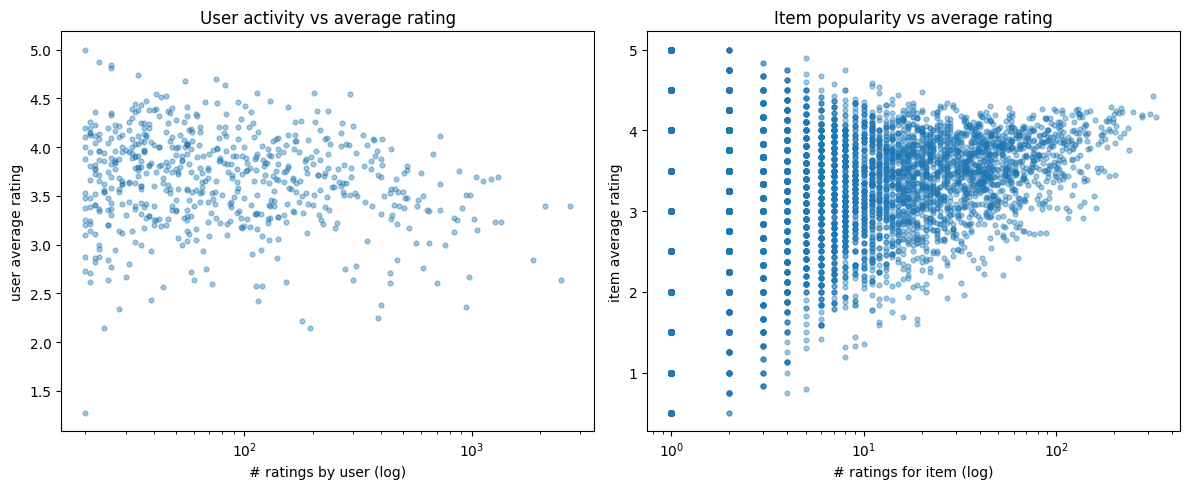

In [76]:
header("Stage 10.2 — User & Item Bias Diagnostics")

# User activity vs avg rating
user_stats = ratings_t.groupby("userId")["rating"].agg(
    avg_rating="mean", n_ratings="size"
)
item_stats = ratings_t.groupby("movieId")["rating"].agg(
    avg_rating="mean", n_ratings="size"
)

# Correlations (Pearson: linear; Spearman: monotonic)
user_pearson = user_stats["n_ratings"].corr(user_stats["avg_rating"], method="pearson")
user_spearman = user_stats["n_ratings"].corr(
    user_stats["avg_rating"], method="spearman"
)

item_pearson = item_stats["n_ratings"].corr(item_stats["avg_rating"], method="pearson")
item_spearman = item_stats["n_ratings"].corr(
    item_stats["avg_rating"], method="spearman"
)

print("OBSERVATION (correlations):")
print(
    f"- corr(user_n_ratings, user_avg_rating) Pearson: {user_pearson:.3f} | Spearman: {user_spearman:.3f}"
)
print(
    f"- corr(item_n_ratings, item_avg_rating) Pearson: {item_pearson:.3f} | Spearman: {item_spearman:.3f}"
)

# Scatter plots (log-scale for counts)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(user_stats["n_ratings"], user_stats["avg_rating"], alpha=0.4, s=12)
ax[0].set_xscale("log")
ax[0].set_title("User activity vs average rating")
ax[0].set_xlabel("# ratings by user (log)")
ax[0].set_ylabel("user average rating")

ax[1].scatter(item_stats["n_ratings"], item_stats["avg_rating"], alpha=0.4, s=12)
ax[1].set_xscale("log")
ax[1].set_title("Item popularity vs average rating")
ax[1].set_xlabel("# ratings for item (log)")
ax[1].set_ylabel("item average rating")

plt.tight_layout()
plt.show()

### What this means
I’m seeing a modest negative relationship between user activity and average rating (Pearson ≈ -0.199, Spearman ≈ -0.135), while item popularity has near-zero monotonic association with average rating (Spearman ≈ 0.040) despite a slight positive linear trend.

### Potential conclusion
I should account for activity bias (heavy users being slightly harsher on average) via user-bias terms/normalization, but I shouldn’t assume popular items are inherently higher-rated since their average ratings are largely independent of popularity once we consider the overall scatter.



### 10.3 Temporal Dynamics Deep Dive

Quantify rating drift (inflation/deflation) and re-plot activity signals with an explicit rating-over-time curve.



Stage 10.3 — Temporal Dynamics Deep Dive


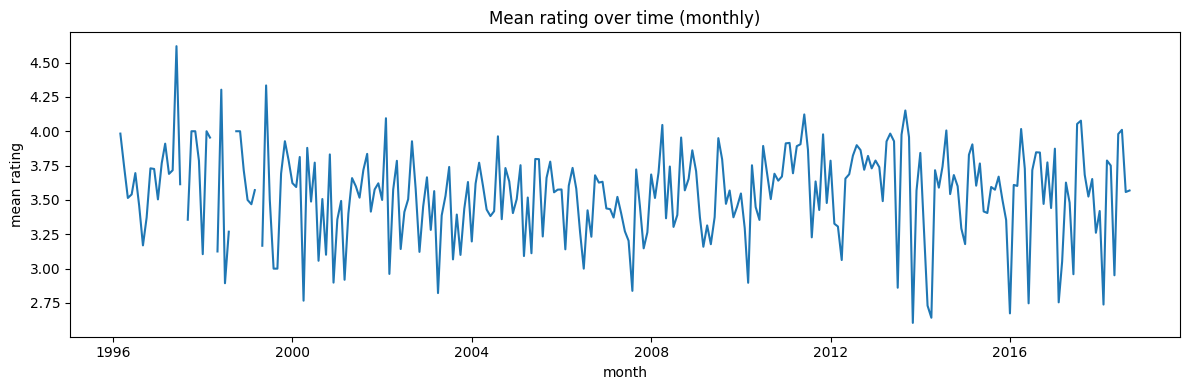

OBSERVATION:
- mean rating series length (months): 271
- rough drift slope (rating units per month index): -4.902915563501175e-05


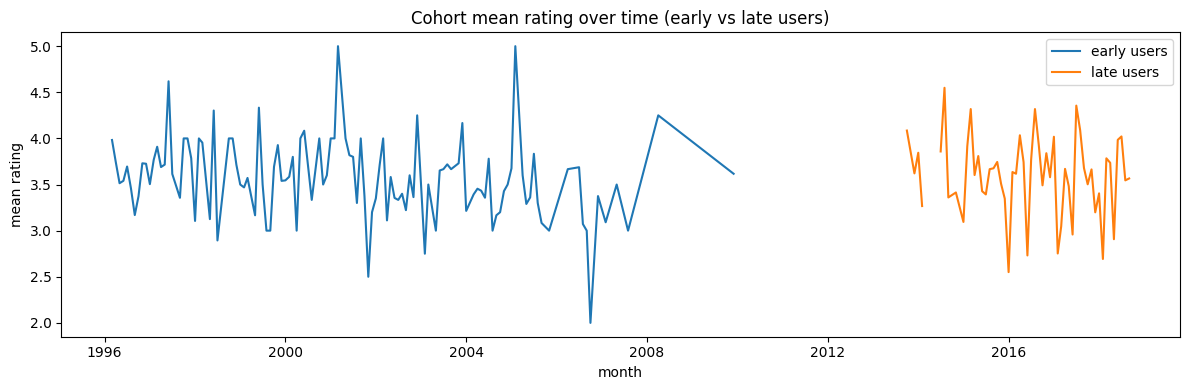

In [77]:
header("Stage 10.3 — Temporal Dynamics Deep Dive")

# Mean rating over time (monthly)
monthly_mean_rating = (
    ratings_t.dropna(subset=["ts"])
    .set_index("ts")["rating"]
    .resample("MS")
    .mean()
    .rename("mean_rating")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_mean_rating.index, monthly_mean_rating.values)
ax.set_title("Mean rating over time (monthly)")
ax.set_xlabel("month")
ax.set_ylabel("mean rating")
plt.tight_layout()
plt.show()

# Simple drift quantification: slope of mean rating vs time index (rough diagnostic)
# (This is descriptive, not a causal claim.)
idx = np.arange(len(monthly_mean_rating), dtype=float)
valid = np.isfinite(monthly_mean_rating.values)
if valid.sum() >= 2:
    slope = np.polyfit(idx[valid], monthly_mean_rating.values[valid], 1)[0]
else:
    slope = float("nan")

print("OBSERVATION:")
print("- mean rating series length (months):", int(len(monthly_mean_rating)))
print("- rough drift slope (rating units per month index):", float(slope))


# Optional cohort-style cut: early vs late users by first interaction date quartiles
first_ts = ratings_t.groupby("userId")["ts"].min().dropna()
q25, q75 = first_ts.quantile([0.25, 0.75])

early_users = set(first_ts[first_ts <= q25].index)
late_users = set(first_ts[first_ts >= q75].index)

cohort = ratings_t.dropna(subset=["ts"]).copy()
cohort["cohort"] = np.where(
    cohort["userId"].isin(early_users),
    "early",
    np.where(cohort["userId"].isin(late_users), "late", "middle"),
)

cohort_monthly = (
    cohort[cohort["cohort"].isin(["early", "late"])]
    .set_index("ts")
    .groupby([pd.Grouper(freq="MS"), "cohort"])["rating"]
    .mean()
    .unstack("cohort")
)

fig, ax = plt.subplots(figsize=(12, 4))
if "early" in cohort_monthly:
    ax.plot(cohort_monthly.index, cohort_monthly["early"], label="early users")
if "late" in cohort_monthly:
    ax.plot(cohort_monthly.index, cohort_monthly["late"], label="late users")
ax.set_title("Cohort mean rating over time (early vs late users)")
ax.set_xlabel("month")
ax.set_ylabel("mean rating")
ax.legend()
plt.tight_layout()
plt.show()

### What this means
I’m seeing that the mean rating fluctuates over time but shows essentially no long-run drift (slope ≈ (-4.9\times10^{-5}) per month index), and the early-vs-late cohort curves look broadly similar within their active periods rather than indicating strong systematic inflation/deflation.

### Potential conclusion
I can treat rating scale stability as roughly consistent over the full timeline, but I should still prefer time-aware evaluation if interaction volume/composition is non-stationary, because changes in who is active (not rating inflation) are the more likely temporal confound.



### 10.4 Sparsity & Coverage Analysis

Quantify how much of the catalog each user sees, and how much of the user base each item reaches.



Stage 10.4 — Sparsity & Coverage
OBSERVATION (sparsity):
- density (interactions / (users * rated_movies)): 0.016999683055613623
- sparsity (1 - density): 0.9830003169443864

OBSERVATION (coverage):
- median % catalog seen per user: 0.007236707041675221
- median % users who rated an item: 0.004918032786885246


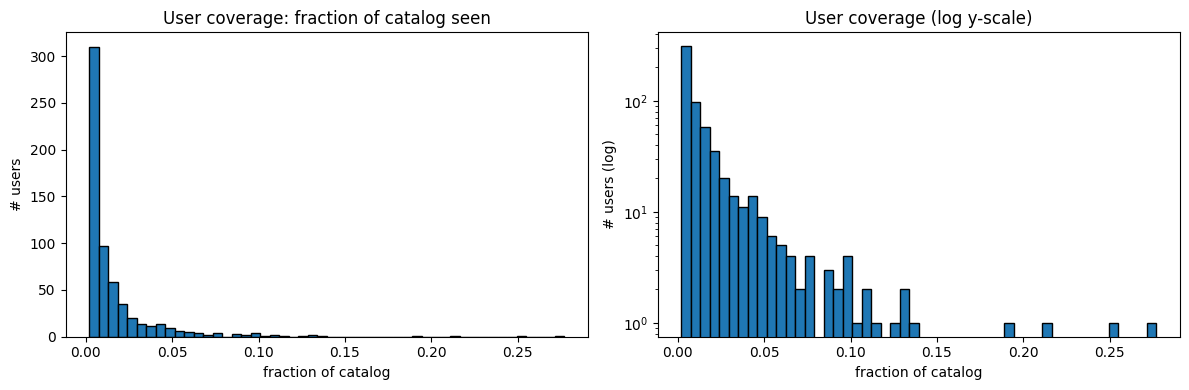

In [78]:
header("Stage 10.4 — Sparsity & Coverage")

# Explicit density (rated-movie universe)
density = N / (U * I_rated)

# % catalog seen per user (rated movies / catalog)
user_unique_items = (
    ratings_t.groupby("userId")["movieId"].nunique().rename("n_unique_items")
)
user_catalog_share = (user_unique_items / I_catalog).rename("catalog_share")

# % users per item (unique users / total users)
item_unique_users = (
    ratings_t.groupby("movieId")["userId"].nunique().rename("n_unique_users")
)
item_user_share = (item_unique_users / U).rename("user_share")

print("OBSERVATION (sparsity):")
print("- density (interactions / (users * rated_movies)):", density)
print("- sparsity (1 - density):", 1 - density)

print("\nOBSERVATION (coverage):")
print("- median % catalog seen per user:", float(user_catalog_share.median()))
print("- median % users who rated an item:", float(item_user_share.median()))

# Plot distribution of user coverage
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(user_catalog_share, bins=50, edgecolor="black")
ax[0].set_title("User coverage: fraction of catalog seen")
ax[0].set_xlabel("fraction of catalog")
ax[0].set_ylabel("# users")

ax[1].hist(user_catalog_share, bins=50, edgecolor="black", log=True)
ax[1].set_title("User coverage (log y-scale)")
ax[1].set_xlabel("fraction of catalog")
ax[1].set_ylabel("# users (log)")

plt.tight_layout()
plt.show()

### What this means
I’m seeing an extremely sparse user–item matrix (density ≈ 0.016999, sparsity ≈ 0.983001) where the median user has only seen ~0.72% of the catalog and the median item is rated by only ~0.49% of users, as shown by the sharply right-skewed coverage distributions.

### Potential conclusion
I should expect severe sparsity-driven limits on personalization (especially for tail users/items) and prioritize strong regularization and bias-aware baselines, because most user–item pairs are unobserved and median coverage is tiny.



### 10.5 Cold-start Quantification

Measure how many users/items have very few interactions/ratings.


In [79]:
header("Stage 10.5 — Cold-start Quantification")

# Using counts from Stage 10 setup
user_counts = ratings_t.groupby("userId").size()
item_counts = ratings_t.groupby("movieId").size()

thresholds = [5, 10]

print("OBSERVATION (cold-start users):")
for t in thresholds:
    pct = float((user_counts <= t).mean())
    print(f"- % users with ≤ {t} interactions: {pct:.2%}")

print("\nOBSERVATION (cold-start items):")
for t in thresholds:
    pct = float((item_counts <= t).mean())
    print(f"- % items with ≤ {t} ratings: {pct:.2%}")


Stage 10.5 — Cold-start Quantification
OBSERVATION (cold-start users):
- % users with ≤ 5 interactions: 0.00%
- % users with ≤ 10 interactions: 0.00%

OBSERVATION (cold-start items):
- % items with ≤ 5 ratings: 66.39%
- % items with ≤ 10 ratings: 78.19%


### What this means
I’m seeing essentially no cold-start at the user level in this dataset (all users have >10 interactions), but severe cold-start at the item level where most movies have very few ratings (≈66.4% have ≤5 and ≈78.2% have ≤10).

### Potential conclusion
I should treat tail items as the primary cold-start bottleneck and consider item-side support thresholds or metadata-aware/hybrid strategies for modeling, since collaborative signals for most items are too sparse to be reliable.



### 10.6 Metadata–Behavior Link

Connect genres to interaction volume and ratings: most popular genres, highest-rated genres, and single- vs multi-genre comparisons.



Stage 10.6 — Metadata–Behavior Link
OBSERVATION (most popular genres by interactions):


,n_interactions
genre,
Drama,41928
Comedy,39053
Action,30635
Thriller,26452
Adventure,24161
Romance,18124
Sci-Fi,17243
Crime,16681
Fantasy,11834



OBSERVATION (highest-rated genres — raw):


,mean_rating,n_interactions
genre,,
Film-Noir,3.920115,870
War,3.808294,4859
Documentary,3.797785,1219
Crime,3.658294,16681
Drama,3.656184,41928
Mystery,3.632460,7674
Animation,3.629937,6988
IMAX,3.618335,4145
Western,3.583938,1930



OBSERVATION (highest-rated genres with n_interactions ≥ 500):


,mean_rating,n_interactions
genre,,
Film-Noir,3.920115,870
War,3.808294,4859
Documentary,3.797785,1219
Crime,3.658294,16681
Drama,3.656184,41928
Mystery,3.632460,7674
Animation,3.629937,6988
IMAX,3.618335,4145
Western,3.583938,1930


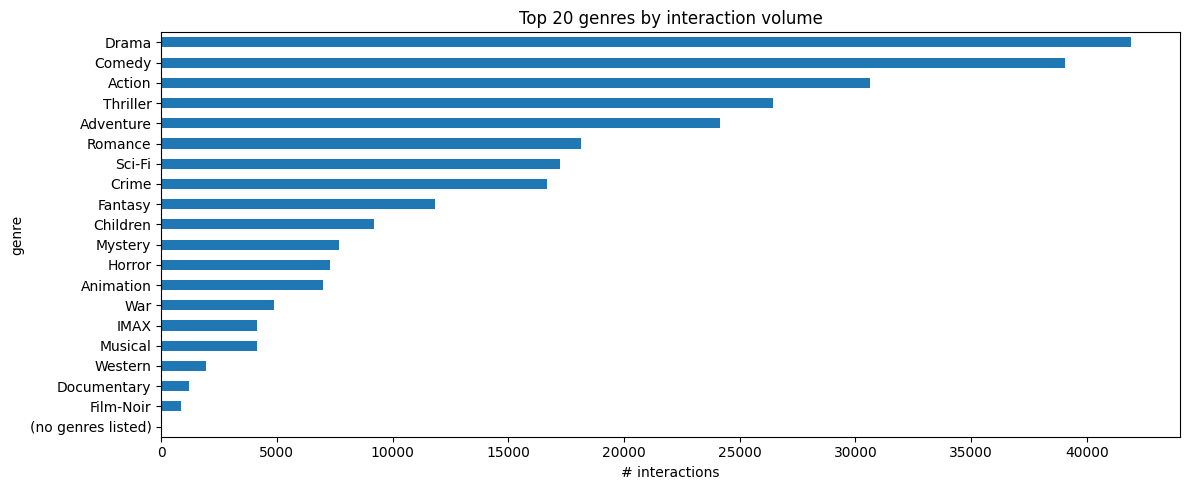

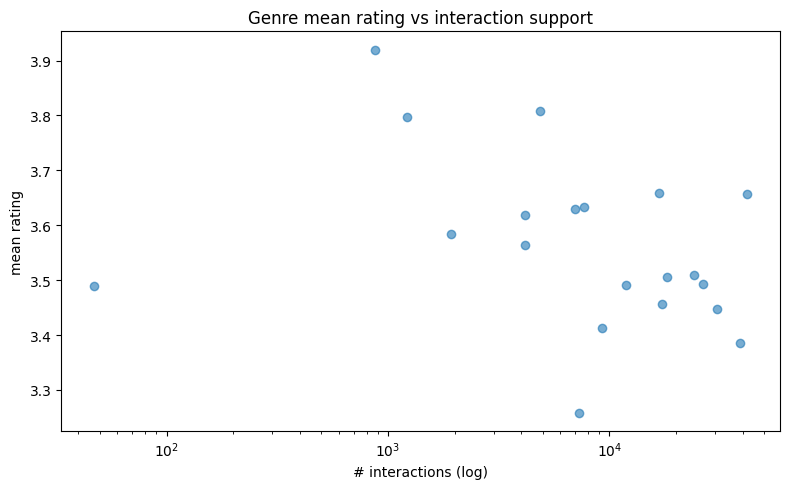


OBSERVATION (single vs multi-genre movies):


,n_movies,mean_of_movie_mean_rating,median_movie_popularity,mean_movie_popularity
genre_type,,,,
single_genre,2845,3.301794,2.0,5.769420
multi_genre,6879,3.246176,3.0,12.272423


In [80]:
header("Stage 10.6 — Metadata–Behavior Link")

# Explode genres per movie, then attach to each rating interaction.
# (This treats multi-genre movies as contributing to multiple genre tallies.)
genres = movies[["movieId", "genres"]].copy()
genres["genres"] = genres["genres"].astype(str)

genres_exploded = genres.assign(genre=genres["genres"].str.split("|")).explode("genre")
genres_exploded["genre"] = genres_exploded["genre"].str.strip()

rm_genre = ratings_t.merge(
    genres_exploded[["movieId", "genre"]], on="movieId", how="left"
)

# Popularity by genre (interaction volume)
genre_pop = (
    rm_genre.groupby("genre")
    .size()
    .rename("n_interactions")
    .sort_values(ascending=False)
)

# Average rating by genre (with support)
genre_rating = rm_genre.groupby("genre")["rating"].agg(
    mean_rating="mean", n_interactions="size"
)

# Single vs multi-genre comparison
n_genres_per_movie = (
    genres_exploded.groupby("movieId")["genre"].nunique().rename("n_genres")
)
movie_genre_type = pd.cut(
    n_genres_per_movie, bins=[0, 1, 100], labels=["single_genre", "multi_genre"]
)

movie_mean_rating = (
    ratings_t.groupby("movieId")["rating"].mean().rename("movie_mean_rating")
)
movie_popularity = ratings_t.groupby("movieId").size().rename("movie_n_ratings")

movie_meta = pd.concat(
    [movie_genre_type.rename("genre_type"), movie_mean_rating, movie_popularity], axis=1
).dropna()

print("OBSERVATION (most popular genres by interactions):")
display(genre_pop.head(15).to_frame())

print("\nOBSERVATION (highest-rated genres — raw):")
display(genre_rating.sort_values("mean_rating", ascending=False).head(15))

# More stable: require minimum interactions
min_n = 500
stable = genre_rating[genre_rating["n_interactions"] >= min_n].sort_values(
    "mean_rating", ascending=False
)
print(f"\nOBSERVATION (highest-rated genres with n_interactions ≥ {min_n}):")
display(stable.head(15))

# Plot: popular genres
fig, ax = plt.subplots(figsize=(12, 5))
genre_pop.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 genres by interaction volume")
ax.set_xlabel("# interactions")
plt.tight_layout()
plt.show()

# Plot: average rating vs support (bubble-less, just scatter)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(genre_rating["n_interactions"], genre_rating["mean_rating"], alpha=0.6)
ax.set_xscale("log")
ax.set_title("Genre mean rating vs interaction support")
ax.set_xlabel("# interactions (log)")
ax.set_ylabel("mean rating")
plt.tight_layout()
plt.show()

# Single vs multi-genre (descriptive)
print("\nOBSERVATION (single vs multi-genre movies):")
display(
    movie_meta.groupby("genre_type").agg(
        n_movies=("movie_mean_rating", "size"),
        mean_of_movie_mean_rating=("movie_mean_rating", "mean"),
        median_movie_popularity=("movie_n_ratings", "median"),
        mean_movie_popularity=("movie_n_ratings", "mean"),
    )
)

### What this means
I’m seeing that interaction volume is concentrated in broad mainstream genres (Drama/Comedy/Action/Thriller), while mean ratings vary by genre with higher-rated niches like Film-Noir/War/Documentary still having sufficient support, and multi-genre movies are much more popular on average but have slightly lower mean ratings than single-genre movies.

### Potential conclusion
I should expect genre-driven exposure effects (popularity) to differ from genre-driven preference (ratings), so using genres as features can help cold-start and segmentation, but I need to control for popularity/selection bias when interpreting “highest-rated genres” and when comparing single- vs multi-genre titles.



### 10.7 Multivariate Insight Layer

Combine magnitude and variance signals to identify:
- heavy users with stable vs volatile ratings
- popular items with stable vs controversial ratings



Stage 10.7 — Multivariate Insight Layer
OBSERVATION:
- user_var rows: 610 | item_var rows: 9724


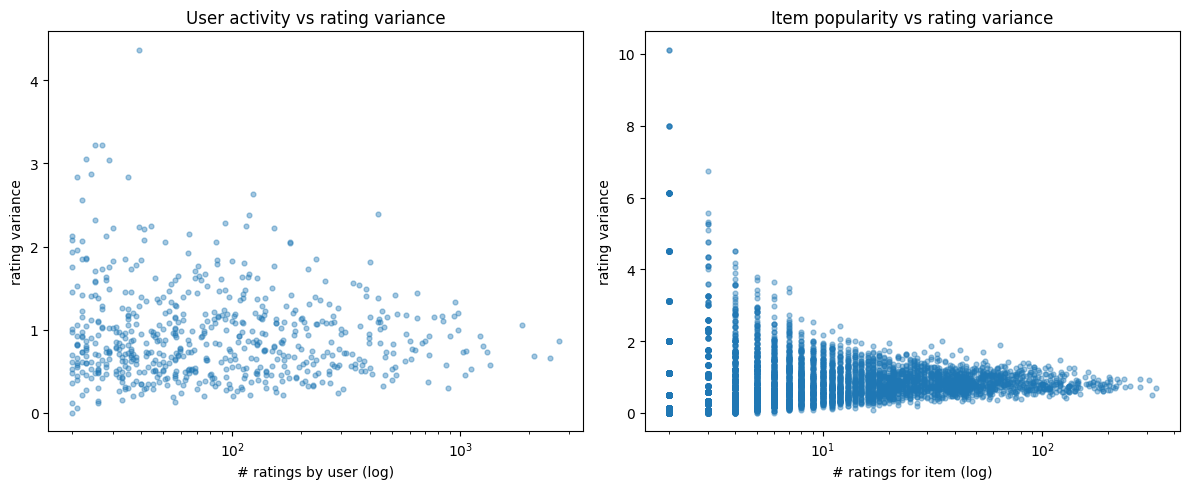


OBSERVATION (stable vs controversial items, n ≥ 50):
Stable (lowest variance):


,title,n,mean,var
movieId,,,,
7143,"Last Samurai, The (2003)",62,3.903226,0.351137
1276,Cool Hand Luke (1967),57,4.271930,0.384555
2291,Edward Scissorhands (1990),80,3.700000,0.402532
2329,American History X (1998),129,4.217054,0.413457
2692,Run Lola Run (Lola rennt) (1998),75,4.000000,0.425676
81845,"King's Speech, The (2010)",58,4.043103,0.441092
440,Dave (1993),76,3.546053,0.447851
2947,Goldfinger (1964),53,3.839623,0.449746
2105,Tron (1982),50,3.340000,0.463673


Controversial (highest variance):


,title,n,mean,var
movieId,,,,
2710,"Blair Witch Project, The (1999)",64,2.796875,1.886657
168,First Knight (1995),54,3.083333,1.686321
2683,Austin Powers: The Spy Who Shagged Me (1999),121,3.198347,1.476997
4308,Moulin Rouge (2001),55,3.590909,1.436027
1407,Scream (1996),70,3.200000,1.430435
1391,Mars Attacks! (1996),86,3.093023,1.391245
784,"Cable Guy, The (1996)",54,2.805556,1.381289
788,"Nutty Professor, The (1996)",82,2.731707,1.377748
3785,Scary Movie (2000),50,2.920000,1.371020


In [81]:
header("Stage 10.7 — Multivariate Insight Layer")

# User: activity vs rating variance
user_var = ratings_t.groupby("userId")["rating"].agg(n="size", mean="mean", var="var")

# Item: popularity vs rating variance
item_var = ratings_t.groupby("movieId")["rating"].agg(n="size", mean="mean", var="var")

print("OBSERVATION:")
print("- user_var rows:", len(user_var), "| item_var rows:", len(item_var))

# Scatter plots (log n)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(user_var["n"], user_var["var"], alpha=0.4, s=12)
ax[0].set_xscale("log")
ax[0].set_title("User activity vs rating variance")
ax[0].set_xlabel("# ratings by user (log)")
ax[0].set_ylabel("rating variance")

ax[1].scatter(item_var["n"], item_var["var"], alpha=0.4, s=12)
ax[1].set_xscale("log")
ax[1].set_title("Item popularity vs rating variance")
ax[1].set_xlabel("# ratings for item (log)")
ax[1].set_ylabel("rating variance")

plt.tight_layout()
plt.show()

# Identify stable vs controversial items among sufficiently-rated movies
min_n_items = 50
items_supported = item_var[item_var["n"] >= min_n_items].dropna()

stable_items = items_supported.sort_values("var", ascending=True).head(10)
controversial_items = items_supported.sort_values("var", ascending=False).head(10)

# Attach titles for readability
items_supported_titles = movies.set_index("movieId")["title"]

stable_items = stable_items.join(items_supported_titles, how="left")
controversial_items = controversial_items.join(items_supported_titles, how="left")

print(f"\nOBSERVATION (stable vs controversial items, n ≥ {min_n_items}):")
print("Stable (lowest variance):")
display(stable_items[["title", "n", "mean", "var"]])

print("Controversial (highest variance):")
display(controversial_items[["title", "n", "mean", "var"]])

### What this means
I’m seeing that rating variance is strongly support-dependent (especially for items: low-(n) items can appear extremely “volatile” due to noise, while higher-(n) items concentrate to moderate variance), and among well-supported movies ((n \ge 50)) there’s a clear split between consensus titles (low variance, generally high means) and polarizing titles (high variance, mixed means).

### Potential conclusion
I should treat variance as a useful “controversy vs consensus” signal only after enforcing a minimum-support threshold, and I can leverage this to avoid over-trusting extreme means from sparse items and to evaluate models separately on stable vs controversial content.



### 10.8 Synthesis 

Strict format:

A. **MEASURED FACTS (quantitative only)**

B. **DETECTED BIASES**

C. **MODELING IMPLICATIONS**

D. **RECOMMENDED NEXT STEPS**


In [82]:
header("Stage 10.8 — Synthesis")

# Reuse metrics computed above (recompute safely if cells ran out of order)
user_counts = ratings_t.groupby("userId").size()
item_counts = ratings_t.groupby("movieId").size()

# Inequality
try:
    gini_users = gini(user_counts)
    gini_items = gini(item_counts)
except Exception:
    gini_users = float("nan")
    gini_items = float("nan")

share_top10_users = float(
    user_counts.sort_values(ascending=False)
    .head(max(1, int(np.ceil(len(user_counts) * 0.10))))
    .sum()
    / user_counts.sum()
)
share_top10_items = float(
    item_counts.sort_values(ascending=False)
    .head(max(1, int(np.ceil(len(item_counts) * 0.10))))
    .sum()
    / item_counts.sum()
)

# Bias correlations
user_stats = ratings_t.groupby("userId")["rating"].agg(
    avg_rating="mean", n_ratings="size"
)
item_stats = ratings_t.groupby("movieId")["rating"].agg(
    avg_rating="mean", n_ratings="size"
)

user_spearman = float(
    user_stats["n_ratings"].corr(user_stats["avg_rating"], method="spearman")
)
item_spearman = float(
    item_stats["n_ratings"].corr(item_stats["avg_rating"], method="spearman")
)

# Sparsity/coverage
N = len(ratings_t)
U = int(ratings_t["userId"].nunique())
I_rated = int(ratings_t["movieId"].nunique())
I_catalog = int(movies["movieId"].nunique())

density = N / (U * I_rated)
user_unique_items = ratings_t.groupby("userId")["movieId"].nunique()
user_catalog_share_median = float((user_unique_items / I_catalog).median())

item_unique_users = ratings_t.groupby("movieId")["userId"].nunique()
item_user_share_median = float((item_unique_users / U).median())

# Cold-start severity
pct_users_le_5 = float((user_counts <= 5).mean())
pct_users_le_10 = float((user_counts <= 10).mean())
pct_items_le_5 = float((item_counts <= 5).mean())
pct_items_le_10 = float((item_counts <= 10).mean())

# Temporal range
unit = guess_unix_unit_from_magnitude(ratings["timestamp"])
ratings_tmp = ratings.copy()
ratings_tmp["ts"] = pd.to_datetime(ratings_tmp["timestamp"], unit=unit, errors="coerce")
ts_min, ts_max = ratings_tmp["ts"].min(), ratings_tmp["ts"].max()

print("A. MEASURED FACTS (quantitative only)")
print(f"- Interactions: {N}")
print(f"- Users: {U}")
print(f"- Rated movies: {I_rated} (catalog: {I_catalog})")
print(
    f"- Matrix density (users × rated_movies): {density:.6f} (sparsity {1 - density:.6f})"
)
print(f"- Median % catalog seen per user: {user_catalog_share_median:.3%}")
print(f"- Median % users per item: {item_user_share_median:.3%}")
print(f"- Gini(users): {gini_users:.3f} | Gini(items): {gini_items:.3f}")
print(f"- Top 10% users share of interactions: {share_top10_users:.2%}")
print(f"- Top 10% items share of interactions: {share_top10_items:.2%}")
print(f"- % users with ≤5: {pct_users_le_5:.2%} | ≤10: {pct_users_le_10:.2%}")
print(f"- % items with ≤5: {pct_items_le_5:.2%} | ≤10: {pct_items_le_10:.2%}")
print(f"- Time range: {ts_min} → {ts_max} (unit guess: {unit})")

print("\nB. DETECTED BIASES")
print(f"- Activity bias (user activity vs avg rating) Spearman: {user_spearman:.3f}")
print(
    f"- Popularity bias (item popularity vs avg rating) Spearman: {item_spearman:.3f}"
)
print(
    "- Temporal bias: interaction volume and composition vary over time (see Stage 7/10.3 plots)"
)


Stage 10.8 — Synthesis
A. MEASURED FACTS (quantitative only)
- Interactions: 100836
- Users: 610
- Rated movies: 9724 (catalog: 9742)
- Matrix density (users × rated_movies): 0.017000 (sparsity 0.983000)
- Median % catalog seen per user: 0.724%
- Median % users per item: 0.492%
- Gini(users): 0.604 | Gini(items): 0.716
- Top 10% users share of interactions: 47.72%
- Top 10% items share of interactions: 60.05%
- % users with ≤5: 0.00% | ≤10: 0.00%
- % items with ≤5: 66.39% | ≤10: 78.19%
- Time range: 1996-03-29 18:36:55 → 2018-09-24 14:27:30 (unit guess: s)

B. DETECTED BIASES
- Activity bias (user activity vs avg rating) Spearman: -0.135
- Popularity bias (item popularity vs avg rating) Spearman: 0.040
- Temporal bias: interaction volume and composition vary over time (see Stage 7/10.3 plots)


### What this means
I’m seeing a quantified picture of the system’s core constraints—extreme sparsity, strong long-tail inequality (especially on items), severe item cold-start, mild activity bias, near-zero popularity–rating coupling, and a long, non-stationary timeline—which together define the dataset’s dominant failure modes.

### Potential conclusion
I should prioritize modeling and evaluation choices that are tail-aware and bias-aware (strong regularization/bias terms, cold-start support via metadata or hybrids, and time-aware or stratified evaluation), because naive collaborative filtering will be disproportionately driven by head items and heavy users despite the weak link between popularity and mean rating.

